# VLM training  notebook 

(using a custom VIT and a pretrained siglip encoder)

Thin orchestration notebook: imports models from `GPT.py`, `ViT.py`, `VLM.py` and other python files needed for training 

In [1]:
import os
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')
sys.path.insert(0, '../src/model')

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoTokenizer

from src.model.gpt import GPT
from src.model.vit import ViT
from src.model.vlm import VLM, CustomViTAdapter, SigLIPAdapter
from src.configs import (
    ConfigParametersLLM,
    ConfigParametersViT,
    ConfigParametersVLM,
    OptimParametersVLM,
)
from src.vision_datasets import val_tfm, train_tfm, build_vlm_dataloaders, build_visual_genome_qa_dataloaders,  build_coco_dataloaders, build_llava_pretrain_dataloaders
from src.train_helper import validate_vlm
from src.utils import vlm_from_config, llm_from_config, vision_encoder_from_config, draw_plot
from src.train_vlm import save_checkpoint, train_vlm
from src.inference_helper import prepare_inference_input


from transformers import SiglipVisionModel

/home/pensativo/code/vision-ai-guide/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup: tokenizer, device, data and model paths

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token


VLM_OUTPUT_DIR = "../outputs/vlm_siglip_stage3"

if  not os.path.exists(VLM_OUTPUT_DIR):
    os.makedirs(VLM_OUTPUT_DIR, exist_ok=True)

## Build configs

In [4]:
vlm_config = {
    "device": device,

    
    "vision_encoder": {
      "type": "siglip",
      "model_name": "google/siglip-base-patch16-224",
      "freeze": False
      },


    "llm": {
          "type": "custom_gpt",
          "config_path": "../configs/custom_gpt_config_params.json",
    },

    "vlm": {
          "batch_size": 32,
          "output_dim": 768 #vision encoder linear projection dim
    },

    "optim": {
            "lr": 1e-4, #learning rate
            "min_lr": 1e-5, #minimum learning rate
            "betas": (0.9, 0.95), #betas
            "eps": 1e-8, #epsilon
            "scheduler": True, #use a learning rate scheduler
            "compile": True, #compile the model
            "autocast": True, #autocast
            "autocast_dtype": torch.bfloat16, #autocast dtype
            "min_lr": 1e-5, #minimum learning rate
            "warmup_steps": 500, #warmup steps
            "max_steps": 40000 #max steps
    }
  }

## Build VLM and optimizer

In [7]:
ckpt = torch.load("../outputs/vlm_siglip/vlm_coco_captions_rope_final.pt")
state_dict = {k.removeprefix("_orig_mod."): v for k, v in ckpt["model"].items()}
                                              
vlm_model = vlm_from_config(vlm_config).to(device)                                                                                                                     
vlm_model.load_state_dict(state_dict)                                                                                                                                                 
vlm_model.to(device)    

opt_cfg_config = vlm_config["optim"]
opt_cfg = OptimParametersVLM(**opt_cfg_config)

optimizer = torch.optim.AdamW(
    [p for p in vlm_model.parameters() if p.requires_grad],
    lr=opt_cfg.lr, betas=opt_cfg.betas, eps=opt_cfg.eps,
)

scheduler = None
if opt_cfg.scheduler is not None:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=opt_cfg.max_steps)

if opt_cfg.compile is not None:
    vlm_model = torch.compile(vlm_model)

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 2002.44it/s, Materializing param=vision_model.post_layernorm.weight]                      
SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNE

## Build dataloaders

In [ ]:
 
COCO_DATA_DIR = "../data/coco"
VG_DATA_DIR = "../data/visual_genome"


train_loader, val_loader = build_llava_pretrain_dataloaders(
      tokenizer,
      batch_size=32,
      max_len=256,
      data_dir="/home/pensativo/datasets/LLaVA-Pretrain-558K",
      val_fraction=0.005,
  )

print(f"LLAVA train batches: {len(train_loader):,}")
print(f"LLAVA val batches:   {len(val_loader):,}")

NameError: name 'vlm_config' is not defined

## VLM stage 2 training with SigLip encoder unfrozen.

In [ ]:
from itertools import cycle
def train_vlm_stage2(
    model,
    train_loaders,
    val_loaders=[],
    optimizer=None,
    device=None,
    opt_cfg=None,
    scheduler=None,
    output_dir=None,
    max_steps=None,
    validation=True,
):
    """Train the VLM model."""
    model.train()

    coco_train_loader, vg_train_loader = train_loaders
    coco_val_loader, vg_val_loader = val_loaders

    coco_iter = cycle(coco_train_loader)
    vg_iter = cycle(vg_train_loader)

    mix_pattern = ["coco", "coco", "vg"]

    step = 0
    train_loss: list[float] = []
    coco_val_losses: list[float] = []
    vg_val_losses: list[float] = []
    print_every = max_steps // 20
    save_every = max_steps // 10

    while step < max_steps:
        source = mix_pattern[step % len(mix_pattern)]

        if source == "coco":
            img, text_tokens, attention_mask, targets = next(coco_iter)
        else:
            img, text_tokens, attention_mask, targets = next(vg_iter)

        
        img = img.to(device)
        text_tokens = text_tokens.to(device)
        attention_mask = attention_mask.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        if opt_cfg.autocast is not None:
            with torch.autocast(device_type="cuda", dtype=opt_cfg.autocast_dtype):
                    logits, loss = model(
                        x_img=img,
                        x_text=text_tokens,
                        targets=targets,
                        attention_mask=attention_mask,
                    )
        else:
                logits, loss = model(
                    x_img=img,
                    x_text=text_tokens,
                    targets=targets,
                    attention_mask=attention_mask,
                )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if opt_cfg.scheduler:
            scheduler.step()

        train_loss.append(loss.item())
        step += 1

        if step % print_every == 0:
            print(f"Step {step} | Loss {loss.item():.4f}")

        if step % save_every == 0:
            ckpt_path = os.path.join(output_dir, f"vlm_coco_captions{step:07d}.pt")
            save_checkpoint(
                    ckpt_path=ckpt_path,
                    step=step,
                    model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    train_loss=train_loss,
                    opt_cfg=opt_cfg,
            )
        
            print(f"Checkpoint saved at step {step}")

            if validation:
                model.eval()
                with torch.inference_mode():
                    coco_val_loss = validate_vlm(
                    model,
                    coco_val_loader,
                    device,
                    max_batches=20,
                    autocast_dtype=opt_cfg.autocast_dtype,
                    )

                    coco_val_losses.append(coco_val_loss)

                    vg_val_loss = validate_vlm(
                        model,
                        vg_val_loader,
                        device,
                        max_batches=20,
                        autocast_dtype=opt_cfg.autocast_dtype,
                    )

                    vg_val_losses.append(vg_val_loss)

                print(f"COCO val loss: {coco_val_loss:.4f}")
                print(f"VG val loss:   {vg_val_loss:.4f}")
                model.train()
   

        if step >= max_steps:
            break

    ckpt_path = os.path.join(output_dir, "vlm_stage2_final.pt")
    torch.save(
        {"step": step, "model": model.state_dict(), "train_loss": train_loss},
        ckpt_path,
    )
    print(f"Saved checkpoint to {ckpt_path}")
    return train_loss, [coco_val_losses, vg_val_losses]

In [10]:
###with rope embeddings
train_loss, val_loss = train_vlm(
    vlm_model, train_loader, val_loader, optimizer, device,
    opt_cfg=opt_cfg, scheduler=scheduler, output_dir=VLM_OUTPUT_DIR,
    max_steps=opt_cfg.max_steps, validation=True
)

W0428 20:23:03.872000 366262 torch/_inductor/utils.py:1727] [0/0_1] Not enough SMs to use max_autotune_gemm mode


Step 2000 | Loss 4.6617
Step 4000 | Loss 4.6492
Checkpoint saved at step 4000
Validation loss: 4.3914
Step 6000 | Loss 4.4010
Step 8000 | Loss 4.7458
Checkpoint saved at step 8000
Validation loss: 4.2870
Step 10000 | Loss 4.8372
Step 12000 | Loss 4.1023
Checkpoint saved at step 12000
Validation loss: 4.1335
Step 14000 | Loss 4.0427
Step 16000 | Loss 3.8841
Checkpoint saved at step 16000
Validation loss: 4.0419
Step 18000 | Loss 3.7850
Step 20000 | Loss 3.6270
Checkpoint saved at step 20000
Validation loss: 3.9523
Step 22000 | Loss 3.4925
Step 24000 | Loss 3.9180
Checkpoint saved at step 24000
Validation loss: 3.8695
Step 26000 | Loss 3.8703
Step 28000 | Loss 3.3070
Checkpoint saved at step 28000
Validation loss: 3.8092
Step 30000 | Loss 3.6512
Step 32000 | Loss 3.7688
Checkpoint saved at step 32000
Validation loss: 3.7547
Step 34000 | Loss 3.7846
Step 36000 | Loss 3.4236
Checkpoint saved at step 36000
Validation loss: 3.7332
Step 38000 | Loss 3.8371
Step 40000 | Loss 3.3486
Checkpoint 

## plot train and val loss

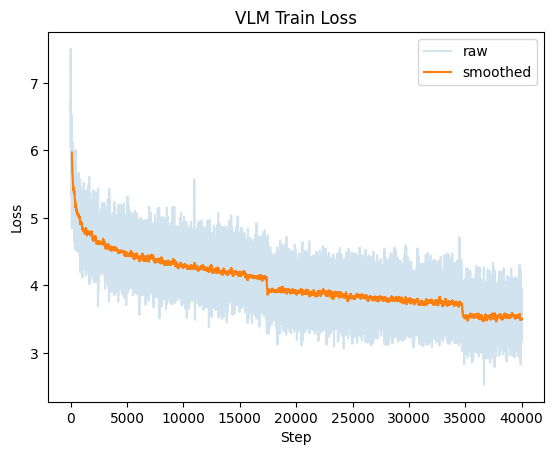

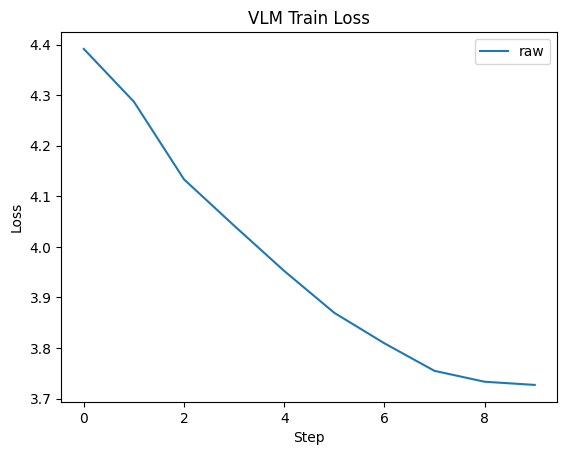

In [11]:
draw_plot(train_loss)
draw_plot(val_loss)

## Inference 

In [12]:
#load VLM model


ckpt = torch.load("../outputs/vlm_siglip_stage2/vlm_coco_captions_rope_final.pt")
state_dict = {k.removeprefix("_orig_mod."): v for k, v in ckpt["model"].items()}



                                              
vlm_model_i = vlm_from_config(vlm_config).to(device)                                                                                                                       
vlm_model_i.load_state_dict(state_dict)                                                                                                                                                 
vlm_model_i.to(device)                                                                                                                                                                  
vlm_model_i.eval()  

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 1234.20it/s, Materializing param=vision_model.post_layernorm.weight]                     
SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEX

VLM(
  (vision_encoder): SigLIPAdapter(
    (model): SiglipVisionModel(
      (vision_model): SiglipVisionTransformer(
        (embeddings): SiglipVisionEmbeddings(
          (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
          (position_embedding): Embedding(196, 768)
        )
        (encoder): SiglipEncoder(
          (layers): ModuleList(
            (0-11): 12 x SiglipEncoderLayer(
              (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
              (self_attn): SiglipAttention(
                (k_proj): Linear(in_features=768, out_features=768, bias=True)
                (v_proj): Linear(in_features=768, out_features=768, bias=True)
                (q_proj): Linear(in_features=768, out_features=768, bias=True)
                (out_proj): Linear(in_features=768, out_features=768, bias=True)
              )
              (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
              (mlp):


image path: /home/pensativo/datasets/LLaVA-Pretrain-558K/images/00114/001146675.jpg
prompt used at idx 800: 'Give a short and clear explanation of the subsequent image.\n<image>'
target used at idx 800: 'personalized jersey, customized baseball jerseys, customized jerseys manufacturers'


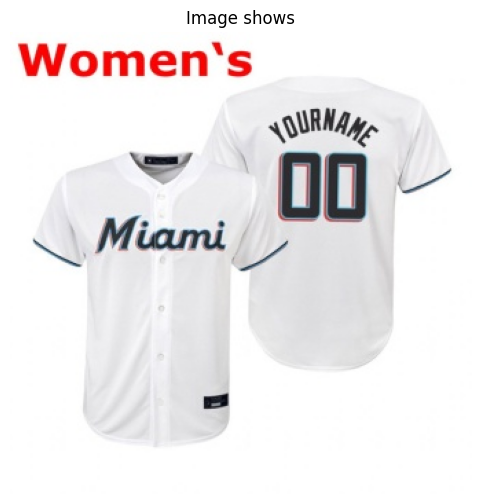

 the new york yankees jersey


In [48]:
idx =  800                                              
                                                                                                                                                                                        
item = val_ds.data[idx]
image_path = os.path.join(val_ds.root, item["image"])

user_turn = next(turn for turn in item["conversations"] if turn["from"] == "human")
assistant_turn = next(turn for turn in item["conversations"] if turn["from"] == "gpt")

prompt_used = user_turn["value"]
caption_used = assistant_turn["value"]

print(f"\nimage path: {image_path}")
print(f"prompt used at idx {idx}: {prompt_used!r}")
print(f"target used at idx {idx}: {caption_used!r}")


messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "path": image_path,
            },
            {
                "type": "text",
                "text": "Image shows"
            },
        ],
    }
]

vlm_model.eval()
inputs = prepare_inference_input(messages, tokenizer, max_len=512, transform=val_tfm)
image = inputs["image"].to(device)
text_tokens = inputs["text_tokens"].to(device)
attention_mask = inputs["attention_mask"].to(device)

with torch.inference_mode():
    generated_ids = vlm_model_i.generate(
        image,
        text_tokens,
        attention_mask,
        max_new_tokens=256,
        eos_token_id=tokenizer.eos_token_id,
    )

image_path = messages[0]["content"][0]["path"]
prompt_text = messages[0]["content"][1]["text"]

pil_img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(pil_img)
plt.axis("off")
plt.title(prompt_text)
plt.show()

print(tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0])

In [4]:
###Stage 3 on visual genome
###with rope embeddings

vlm_config = {
    "device": device,

    
    "vision_encoder": {
      "type": "siglip",
      "model_name": "google/siglip-base-patch16-224",
      "freeze": False
      },


    "llm": {
          "type": "custom_gpt",
          "config_path": "../configs/custom_gpt_config_params.json",
    },

    "vlm": {
          "batch_size": 32,
          "output_dim": 768 #vision encoder linear projection dim
    },

    "optim": {
            "lr": 2e-5, #learning rate
            "min_lr": 1e-6, #minimum learning rate
            "betas": (0.9, 0.95), #betas
            "eps": 1e-8, #epsilon
            "scheduler": True, #use a learning rate scheduler
            "compile": True, #compile the model
            "autocast": True, #autocast
            "autocast_dtype": torch.bfloat16, #autocast dtype
            "warmup_steps": 200, #warmup steps
            "max_steps": 15000 #max steps
    }
  }



ckpt = torch.load("../outputs/vlm_siglip_stage2/vlm_coco_captions_rope_final.pt")
state_dict = {k.removeprefix("_orig_mod."): v for k, v in ckpt["model"].items()}
                                              
vlm_model = vlm_from_config(vlm_config).to(device)                                                                                                                     
vlm_model.load_state_dict(state_dict)                                                                                                                                                 
vlm_model.to(device)    

opt_cfg_config = vlm_config["optim"]
opt_cfg = OptimParametersVLM(**opt_cfg_config)

optimizer = torch.optim.AdamW(
    [p for p in vlm_model.parameters() if p.requires_grad],
    lr=opt_cfg.lr, betas=opt_cfg.betas, eps=opt_cfg.eps,
)

scheduler = None
if opt_cfg.scheduler is not None:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=opt_cfg.max_steps)

if opt_cfg.compile is not None:
    vlm_model = torch.compile(vlm_model)



VG_DATA_DIR = "../data/visual_genome"



vg_train_loader, vg_val_loader = build_visual_genome_qa_dataloaders(
      tokenizer,
      batch_size=vlm_config["vlm"]["batch_size"],
      max_len=256,
      num_workers=4,
      data_dir=VG_DATA_DIR,
)

print(f"VG train batches:   {len(vg_train_loader):,}")
print(f"VG val batches:     {len(vg_val_loader):,}")

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 1338.82it/s, Materializing param=vision_model.post_layernorm.weight]                      
SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNE

VG train batches:   22,506
VG val batches:     203


In [5]:
train_loss_vg, val_loss_vg = train_vlm(
    vlm_model, vg_train_loader, vg_val_loader, optimizer, device,
    opt_cfg=opt_cfg, scheduler=scheduler, output_dir=VLM_OUTPUT_DIR,
    max_steps=opt_cfg.max_steps, validation=True
)

W0429 13:34:13.009000 409767 torch/_inductor/utils.py:1727] [0/0_1] Not enough SMs to use max_autotune_gemm mode


Step 750 | Loss 1.4570
Step 1500 | Loss 1.1290
Checkpoint saved at step 1500
Validation loss: 1.3251
Step 2250 | Loss 1.0486
Step 3000 | Loss 1.3759
Checkpoint saved at step 3000
Validation loss: 1.2459
Step 3750 | Loss 0.8138
Step 4500 | Loss 1.2877
Checkpoint saved at step 4500
Validation loss: 1.2269
Step 5250 | Loss 1.5468
Step 6000 | Loss 1.5696
Checkpoint saved at step 6000
Validation loss: 1.2118
Step 6750 | Loss 0.9578
Step 7500 | Loss 0.9745
Checkpoint saved at step 7500
Validation loss: 1.1900
Step 8250 | Loss 0.9403
Step 9000 | Loss 1.1562
Checkpoint saved at step 9000
Validation loss: 1.1608
Step 9750 | Loss 1.2072
Step 10500 | Loss 1.2534
Checkpoint saved at step 10500
Validation loss: 1.1554
Step 11250 | Loss 1.0349
Step 12000 | Loss 1.1928
Checkpoint saved at step 12000
Validation loss: 1.1488
Step 12750 | Loss 1.2444
Step 13500 | Loss 0.5975
Checkpoint saved at step 13500
Validation loss: 1.1491
Step 14250 | Loss 0.5431
Step 15000 | Loss 0.8101
Checkpoint saved at step 

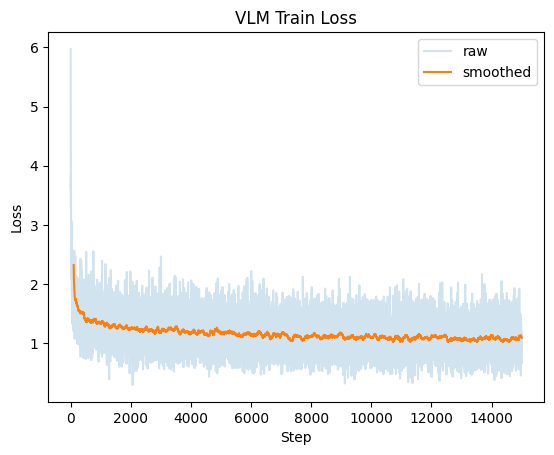

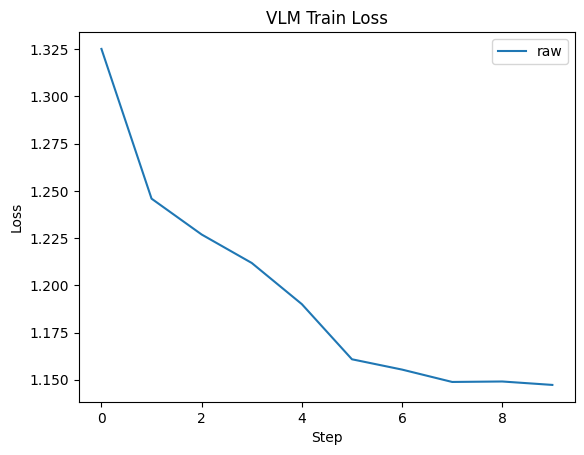

In [6]:
draw_plot(train_loss_vg)
draw_plot(val_loss_vg)

In [ ]:
ckpt = torch.load("../outputs/vlm_siglip_stage3/vlm_coco_captions_rope_final.pt")
state_dict = {k.removeprefix("_orig_mod."): v for k, v in ckpt["model"].items()}



                                              
vlm_model_i = vlm_from_config(vlm_config).to(device)                                                                                                                       
vlm_model_i.load_state_dict(state_dict)                                                                                                                                                 
vlm_model_i.to(device)                                                                                                                                                                  
vlm_model_i.eval()  


image path: ../data/visual_genome/images/2381727.jpg
User prompt at 70: '<image>\nWhat is above the stove?'
target assistent response at 70: 'A microwave.'


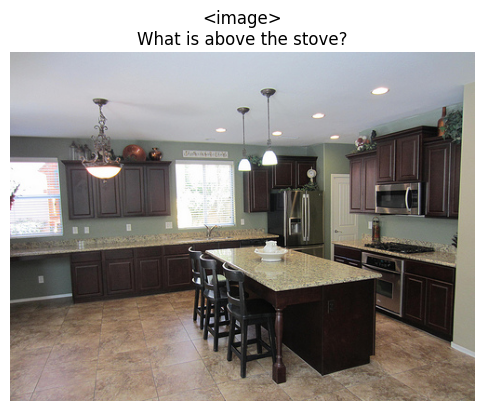

In [ ]:
idx = 70
val_ds = vg_val_loader.dataset
item = val_ds.data[idx]

image_path = os.path.join(val_ds.root, item["image"])
prompt_used = next(turn for turn in item["conversations"] if turn["from"] == "user")["value"]
target_used = next(turn for turn in item["conversations"] if turn["from"] == "assistant")["value"]




print(f"\nimage path: {image_path}")
print(f"User prompt at {idx}: {prompt_used!r}")
print(f"target assistent response at {idx}: {target_used!r}")

clean_prompt = prompt_used.replace("<image>", "").strip()
prompt = next(
        turn["value"] for turn in item["conversations"] if turn["from"] == "user"
)



messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "path": image_path,
            },
            {
                "type": "text",
                "text": "summarize this image"
            },
        ],
    }
]

vlm_model.eval()
inputs = prepare_inference_input(messages, tokenizer, max_len=512, transform=val_tfm)
image = inputs["image"].to(device)
text_tokens = inputs["text_tokens"].to(device)
attention_mask = inputs["attention_mask"].to(device)

with torch.inference_mode():
    generated_ids = vlm_model.generate(
        image,
        text_tokens,
        attention_mask,
        max_new_tokens=256,
        eos_token_id=tokenizer.eos_token_id,
    )

image_path = messages[0]["content"][0]["path"]
prompt_text = messages[0]["content"][1]["text"]

pil_img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(pil_img)
plt.axis("off")
plt.title(prompt_text)
plt.show()

print(tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0])